# FCS Fitting Notebook

A notebook for simple FCS fitting.
Any model which you wish to include should be written in the script `fcs_plotting`.

Package requirements:
- matplotlib
- numpy
- lmfit

In [77]:
import matplotlib.pyplot as plt
import numpy as np

from lmfit import Model, Parameters

from IPython.display import display

from fcs_models import *
from fcs_plotting import *

This is where you change all of the variables for the script.

For a standard fitting, change the variable `FILEPATH` to the location of the .txt file you wish to fit (the first column is assumed to be the lag time, the second to fifth the correlation functions and sixth to ninth the standard deviations).
Then, change the `MODEL` to whatever model you wish to use to fit the curve.
`lmfit` allows for fitting bounds to be implemented (https://lmfit.github.io/lmfit-py/bounds.html), and typical regimes are included in `VALUE_BOUNDS` in SI units (distance: metres, time: seconds).

If you are performing a calibration measurement, use model functions ending in `_fixD` such that the script will automatically force the diffusion coefficient to be whatever value you set in `DEFAULT_VALUES`.
Standard diffusion coefficients of dyes can be found here: https://www.picoquant.com/images/uploads/page/files/7353/appnote_diffusioncoefficients.pdf

In [78]:
plt.rcParams['figure.figsize'] = [10, 5]
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 16
plt.rcParams['text.usetex'] = False # use LaTeX for all text. If you don't have LaTeX installed, you can set this to False
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'

TIME_BOUNDS = [1e-4, 1e0] # upper and lower bounds for lag times to be fitted in seconds
FILEPATH = r"/Users/xiaohanzhou/Desktop/Data/FCS Results/Basal_Signaling/M1_G11_CAR_May1_1.txt"

COLORS = ["#007FA3", "#6D247A", "#DC4633", "#8DBF2E"]
LABELS = ['CF1', 'CF2', 'CF3', 'CF4']

OVCF_r = 1.4
OVCF_g = 1


In [79]:


MODEL_GPCR = CF_2da_2c_1T
DEFAULT_VALUES = {'n': 2, 'tauD': 0.2, 'tauD1': 0.12, 'D' : 4.25e-10, 'r0' : 3.21e-7, 's' : 6.68, 'offset' : 0, 'a1' : 1, 'tauD2' : 0.88, 'a2': 1, 'f1' : 0.5, 'tautr' : 0.00341, 'T' : 0.1, 'tautr2' : 1e-6, 'T2' : 0.1,'tauD3':0.00341,'f2':0.2}
VALUE_BOUNDS = {'n': [0.001, 1000], 'tauD': [1e-2, 1], 'tauD1': [1e-2, 0.5], 'a1': [0,2],'tauD2': [1e-2, 2], 'a2': [0,2],'tauD3': [1e-7, 1e-2], 'f1': [0,1], 'f2': [0,1], 'D': [1e-13,1e-9], 'r0' : [1e-9,1e-6], 's': [1, 20], 'offset' : [-1, 1], 'tautr' : [1e-4, 1e-2], 'T' : [1e-8, 1], 'tautr2' : [1e-8, 1e-3], 'T2' : [1e-8, 1], 'tautr3' : [1e-8, 1e-3], 'T3' : [1e-8, 1],'tauD3':[1e-4, 1e-2],'f2' : [1e-8, 1]}
VARY = {'n': True, 'tauD': True, 'tauD1': True, 'a1': False, 'tauD2': True, 'a2': False, 'tauD3': True, 'f1': True, 'f2': True, 'D': True, 'r0' : False, 's' : False, 'offset' : True, 'tautr' : False, 'T' : True, 'tautr2' : True, 'T2' : True, 'tautr3' : True, 'T3' : True,'tauD3':True, 'f2':True}

CURR_PARAMS = MODEL_GPCR.__code__.co_varnames[1:MODEL_GPCR.__code__.co_argcount]
params = Parameters()
for param in CURR_PARAMS:
    if "fixD" in MODEL_GPCR.__name__ and param == "D":
        params.add(param, value=DEFAULT_VALUES[param], vary=False, min=VALUE_BOUNDS[param][0], max=VALUE_BOUNDS[param][1])
    else:
        params.add(param, value=DEFAULT_VALUES[param], vary=VARY[param], min=VALUE_BOUNDS[param][0], max=VALUE_BOUNDS[param][1])
params
params_GPCR = params

In [80]:
MODEL_GPCR_R = CF_2da_2c_1T
DEFAULT_VALUES = {'n': 2, 'tauD': 0.2, 'tauD1': 0.12, 'D' : 4.25e-10, 'r0' : 2.8e-7, 's' : 7.96, 'offset' : 0, 'a1' : 1, 'tauD2' : 0.88, 'a2': 1, 'f1' : 0.5, 'tautr' : 0.00341, 'T' : 0.1, 'tautr2' : 1e-6, 'T2' : 0.1,'tauD3':0.00341,'f2':0.2}
VALUE_BOUNDS = {'n': [0.001, 1000], 'tauD': [1e-2, 1], 'tauD1': [1e-2, 0.5], 'a1': [0,2],'tauD2': [1e-2, 2], 'a2': [0,2],'tauD3': [1e-7, 1e-2], 'f1': [0,1], 'f2': [0,1], 'D': [1e-13,1e-9], 'r0' : [1e-9,1e-6], 's': [1, 20], 'offset' : [-1, 1], 'tautr' : [1e-4, 1e-2], 'T' : [1e-8, 1], 'tautr2' : [1e-8, 1e-3], 'T2' : [1e-8, 1], 'tautr3' : [1e-8, 1e-3], 'T3' : [1e-8, 1],'tauD3':[1e-4, 1e-2],'f2' : [1e-8, 1]}
VARY = {'n': True, 'tauD': True, 'tauD1': True, 'a1': False, 'tauD2': True, 'a2': False, 'tauD3': True, 'f1': True, 'f2': True, 'D': True, 'r0' : False, 's' : False, 'offset' : True, 'tautr' : False, 'T' : True, 'tautr2' : True, 'T2' : True, 'tautr3' : True, 'T3' : True,'tauD3':True, 'f2':True}

CURR_PARAMS = MODEL_GPCR.__code__.co_varnames[1:MODEL_GPCR.__code__.co_argcount]
params = Parameters()
for param in CURR_PARAMS:
    if "fixD" in MODEL_GPCR.__name__ and param == "D":
        params.add(param, value=DEFAULT_VALUES[param], vary=False, min=VALUE_BOUNDS[param][0], max=VALUE_BOUNDS[param][1])
    else:
        params.add(param, value=DEFAULT_VALUES[param], vary=VARY[param], min=VALUE_BOUNDS[param][0], max=VALUE_BOUNDS[param][1])
params
params_GPCR_R = params

MODEL_GPCR_X = CF_2da_2c_1T
DEFAULT_VALUES = {'n': 2, 'tauD': 0.2, 'tauD1': 0.12, 'D' : 4.25e-10, 'r0' : 2.8e-7, 's' : 6.68, 'offset' : 0, 'a1' : 1, 'tauD2' : 0.88, 'a2': 1, 'f1' : 0.5, 'tautr' : 0.00341, 'T' : 0.1, 'tautr2' : 1e-6, 'T2' : 0.1,'tauD3':0.00341,'f2':0.2}
VALUE_BOUNDS = {'n': [0.001, 1000], 'tauD': [1e-2, 1], 'tauD1': [1e-2, 0.5], 'a1': [0,2],'tauD2': [1e-2, 2], 'a2': [0,2],'tauD3': [1e-7, 1e-2], 'f1': [0,1], 'f2': [0,1], 'D': [1e-13,1e-9], 'r0' : [1e-9,1e-6], 's': [1, 20], 'offset' : [-1, 1], 'tautr' : [1e-4, 1e-2], 'T' : [1e-8, 1], 'tautr2' : [1e-8, 1e-3], 'T2' : [1e-8, 1], 'tautr3' : [1e-8, 1e-3], 'T3' : [1e-8, 1],'tauD3':[1e-4, 1e-2],'f2' : [1e-8, 1]}
VARY = {'n': True, 'tauD': True, 'tauD1': True, 'a1': False, 'tauD2': True, 'a2': False, 'tauD3': True, 'f1': True, 'f2': True, 'D': True, 'r0' : False, 's' : False, 'offset' : True, 'tautr' : False, 'T' : True, 'tautr2' : True, 'T2' : True, 'tautr3' : True, 'T3' : True,'tauD3':True, 'f2':True}

CURR_PARAMS = MODEL_GPCR.__code__.co_varnames[1:MODEL_GPCR.__code__.co_argcount]
params = Parameters()
for param in CURR_PARAMS:
    if "fixD" in MODEL_GPCR.__name__ and param == "D":
        params.add(param, value=DEFAULT_VALUES[param], vary=False, min=VALUE_BOUNDS[param][0], max=VALUE_BOUNDS[param][1])
    else:
        params.add(param, value=DEFAULT_VALUES[param], vary=VARY[param], min=VALUE_BOUNDS[param][0], max=VALUE_BOUNDS[param][1])
params
params_GPCR_X = params

In [81]:
MODEL_GP = CF_2d_2c
DEFAULT_VALUES = {'n': 0.2, 'tauD': 3.4e-2, 'tauD1': 3e-2, 'D' : 4.25e-10, 'r0' : 2.8e-7, 's' : 7.96, 'offset' : 0, 'a1' : 1, 'tauD2' : 3.8e-2, 'a2': 1, 'f1' : 0.5, 'tautr' : 1e-3, 'T' : 0, 'tautr2' : 1e-6, 'T2' : 0.1}
VALUE_BOUNDS = {'n': [0.001, 1000], 'tauD': [1e-3, 1e-1], 'tauD1': [1e-4, 1e-2], 'a1': [0,2],'tauD2': [1e-3, 1], 'a2': [0,2],'tauD3': [1e-7, 1e-2], 'f1': [0,1], 'f2': [0,1], 'D': [1e-13,1e-9], 'r0' : [1e-9,1e-6], 's': [1, 20], 'offset' : [-1, 1], 'tautr' : [1e-4, 1e-2], 'T' : [1e-8, 1], 'tautr2' : [1e-8, 1e-3], 'T2' : [1e-8, 1], 'tautr3' : [1e-8, 1e-3], 'T3' : [1e-8, 1]}
VARY = {'n': True, 'tauD': True, 'tauD1': True, 'a1': True, 'tauD2': True, 'a2': True, 'tauD3': True, 'f1': True, 'f2': True, 'D': True, 'r0' : False, 's' : False, 'offset' : True, 'tautr' : True, 'T' : True, 'tautr2' : True, 'T2' : True, 'tautr3' : True, 'T3' : True}

CURR_PARAMS = MODEL_GP.__code__.co_varnames[1:MODEL_GP.__code__.co_argcount]
params = Parameters()
for param in CURR_PARAMS:
    if "fixD" in MODEL_GP.__name__ and param == "D":
        params.add(param, value=DEFAULT_VALUES[param], vary=False, min=VALUE_BOUNDS[param][0], max=VALUE_BOUNDS[param][1])
    else:
        params.add(param, value=DEFAULT_VALUES[param], vary=VARY[param], min=VALUE_BOUNDS[param][0], max=VALUE_BOUNDS[param][1])
params
params_GP = params


In [82]:
data = np.loadtxt(FILEPATH)

In [83]:
lag_times = data[:,0]
masked_times = np.logical_and(lag_times > TIME_BOUNDS[0], lag_times < TIME_BOUNDS[1])
select_data = data[masked_times]

In [84]:
lag_times = select_data[:,0]
cf1 = select_data[:,1]
errors1 = select_data[:,5]
cf2 = select_data[:,2]
errors2 = select_data[:,6]
cf3 = select_data[:,3]
errors3 = select_data[:,7]
cf4 = select_data[:,4]
errors4 = select_data[:,8]

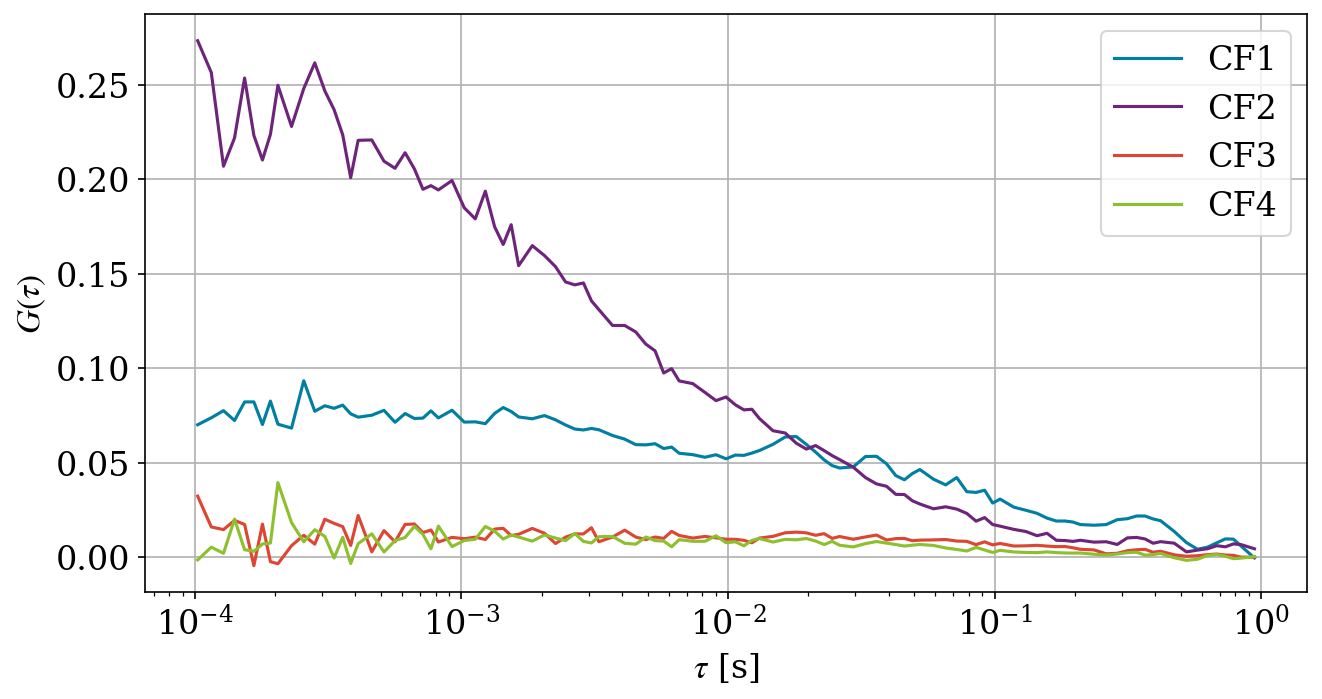

In [85]:
fig1 = plt.figure(1)

plt.plot(lag_times, cf1, label=LABELS[0], color=COLORS[0])
plt.plot(lag_times, cf2, label=LABELS[1], color=COLORS[1])
plt.plot(lag_times, cf3, label=LABELS[2], color=COLORS[2])
plt.plot(lag_times, cf4, label=LABELS[3], color=COLORS[3])
plt.semilogx()
plt.legend()
plt.xlabel(r'$\tau$ [s]')
plt.ylabel(r'$G(\tau)$')
plt.grid()
plt.show()

In [86]:
model1 = Model(MODEL_GP)
model2 = Model(MODEL_GP)
model3 = Model(MODEL_GP)
model4 = Model(MODEL_GP)

In [87]:
result1 = model1.fit(cf1, params_GP, taus=lag_times, weights=weight_function(errors1))
result2 = model2.fit(cf2, params_GP, taus=lag_times, weights=weight_function(errors2))
result3 = model3.fit(cf3, params_GP, taus=lag_times, weights=weight_function(errors3))
result4 = model4.fit(cf4, params_GP, taus=lag_times, weights=weight_function(errors4))

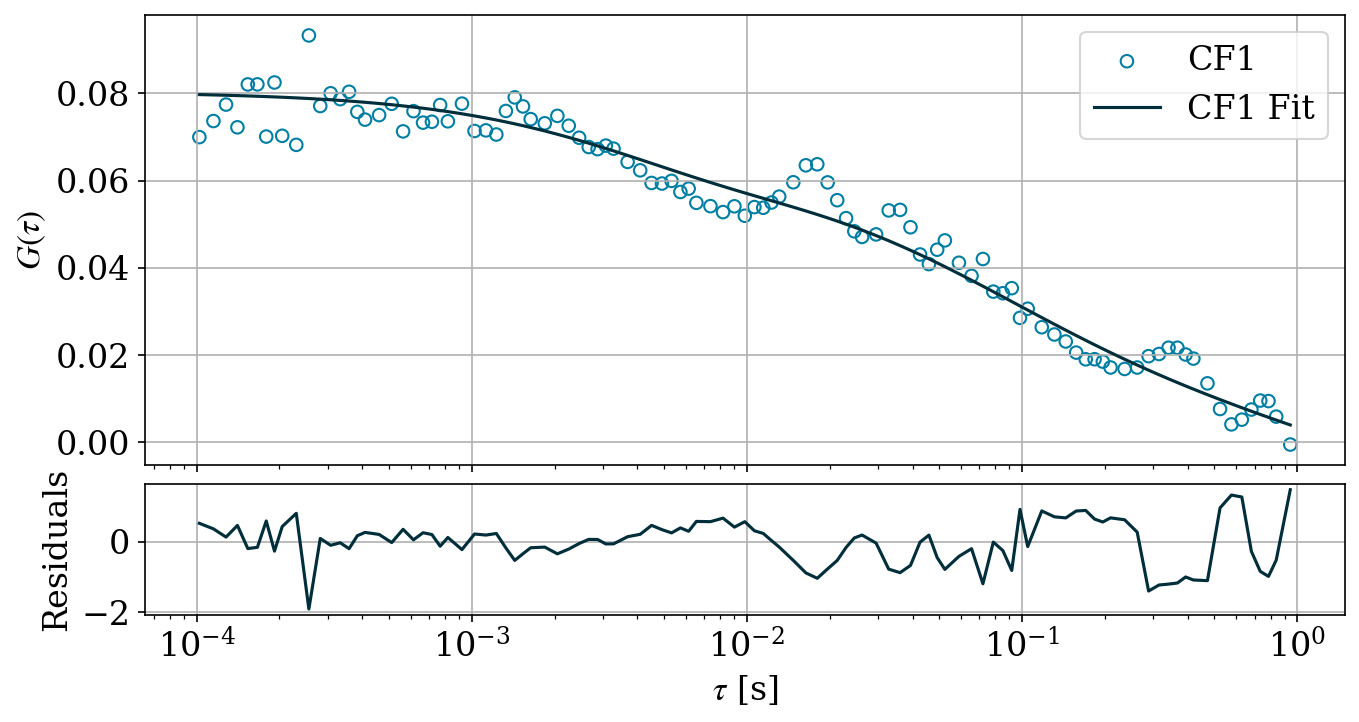

name,value,standard error,relative error,initial value,min,max,vary
n,12.5942187,15.6663334,(124.39%),2,1.0000e-03,1000.00000,True
tauD1,0.08215670,0.04561051,(55.52%),0.12,0.01000000,0.50000000,True
a1,1.00000000,0.00000000,(0.00%),1,0.00000000,2.00000000,False
tauD2,1.99999999,17.6218522,(881.09%),0.88,0.01000000,2.00000000,True
a2,1.00000000,0.00000000,(0.00%),1,0.00000000,2.00000000,False
f1,0.68848142,0.64606343,(93.84%),0.5,0.00000000,1.00000000,True
tautr,0.00341000,0.00000000,(0.00%),0.00341,1.0000e-04,0.01000000,False
T,0.18595807,0.17669203,(95.02%),0.1,1.0000e-08,1.00000000,True
offset,-0.01720058,0.10036394,(583.49%),0,-1.00000000,1.00000000,True


Metric,Score
Reduced Chi-Squared,0.4141
AIC,-87.6190
R Squared,0.9634


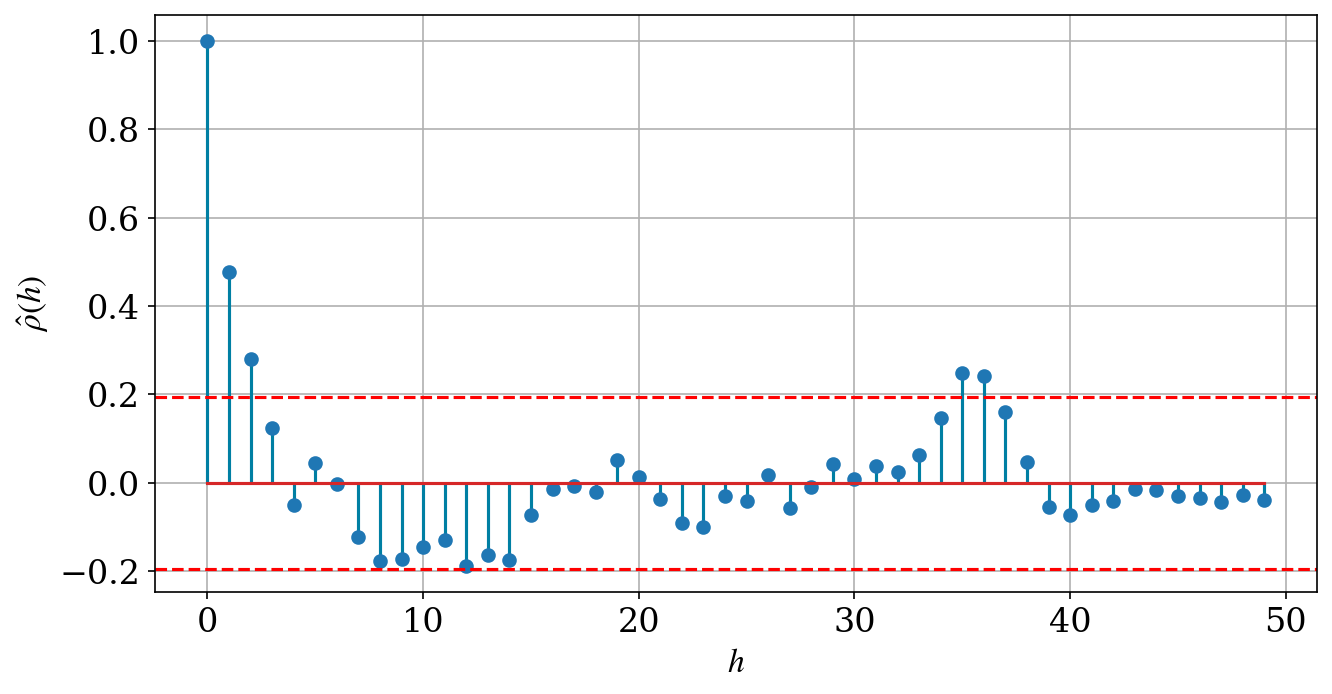

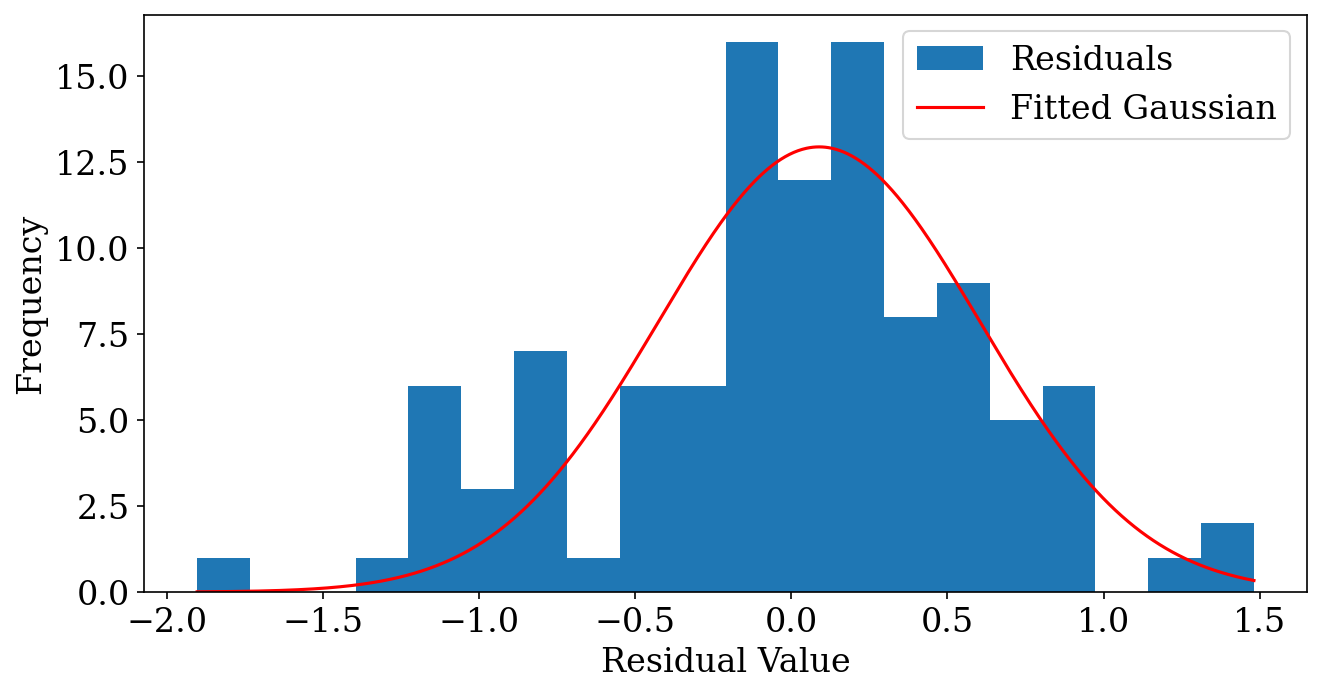

In [88]:
model_plot(lag_times, cf1, result1, LABELS[0], COLORS[0])
display(result1.params)
display(fit_evaluation(result1))
residual_autocorrelation(result1, color=COLORS[0])
residuals_histogram(result1)
T_CF1 = result1.best_values['T']
n_CF1 = result1.best_values['n']
G0_CF1 = G0(n_CF1,T_CF1)

In [89]:
diffusion_coefficient(0.006,2.85e-7)*10**12
#concentration(3.41+0.14,285,7.9)
G0(6.72,0.4)
#result2.best_values['T']

0.08928571428571429

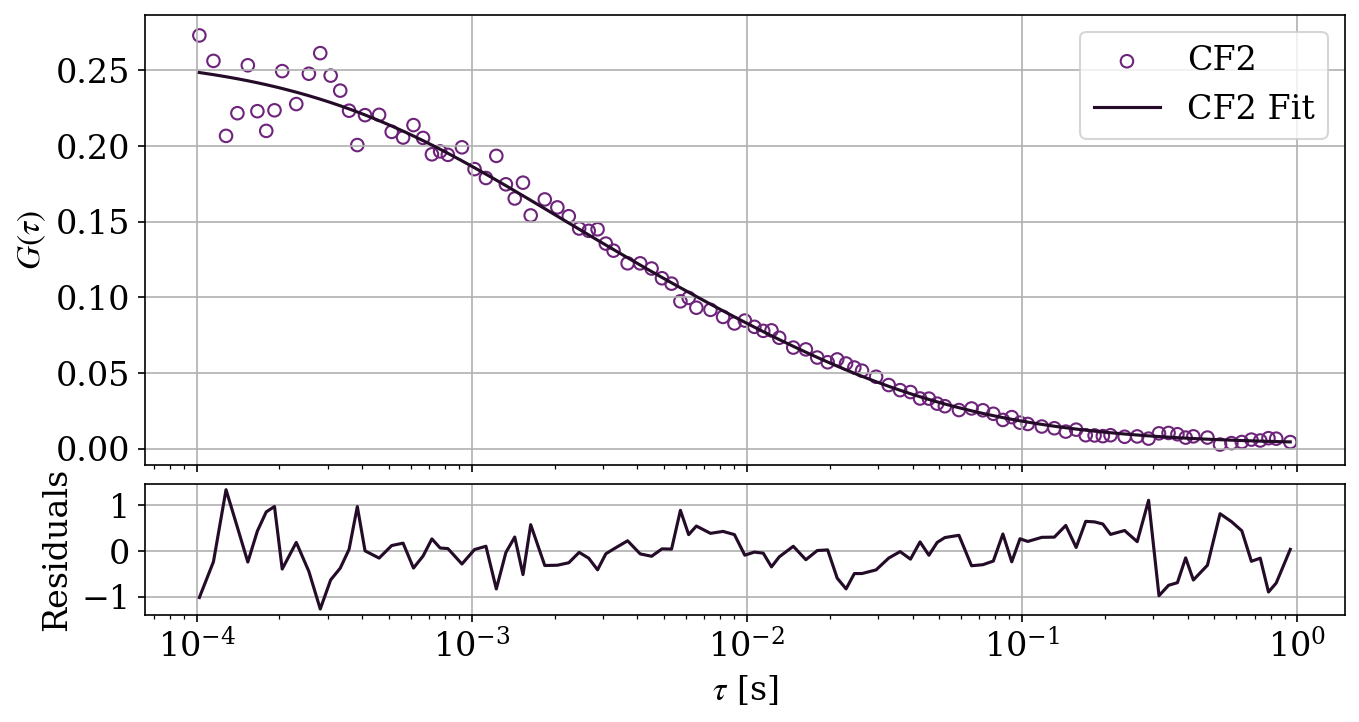

name,value,standard error,relative error,initial value,min,max,vary
n,3.87301101,0.07636233,(1.97%),0.2,1.0000e-03,1000.00000,True
tauD1,0.00126032,0.00122906,(97.52%),0.01,1.0000e-04,0.01000000,True
tauD2,0.01479773,0.00497649,(33.63%),0.038,1.0000e-03,1.00000000,True
f1,0.58990330,0.18630952,(31.58%),0.5,0.00000000,1.00000000,True
offset,0.00262031,4.6161e-04,(17.62%),0,-1.00000000,1.00000000,True


Metric,Score
Reduced Chi-Squared,0.2373
AIC,-147.5897
R Squared,0.9899


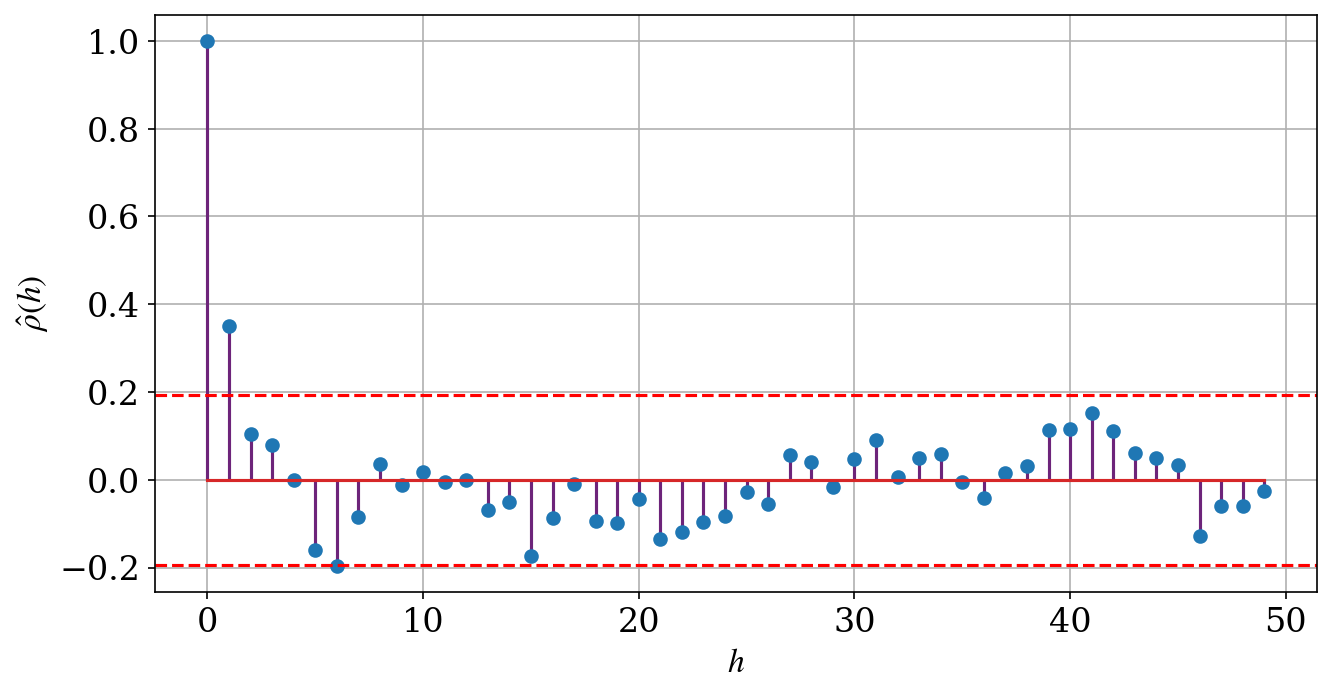

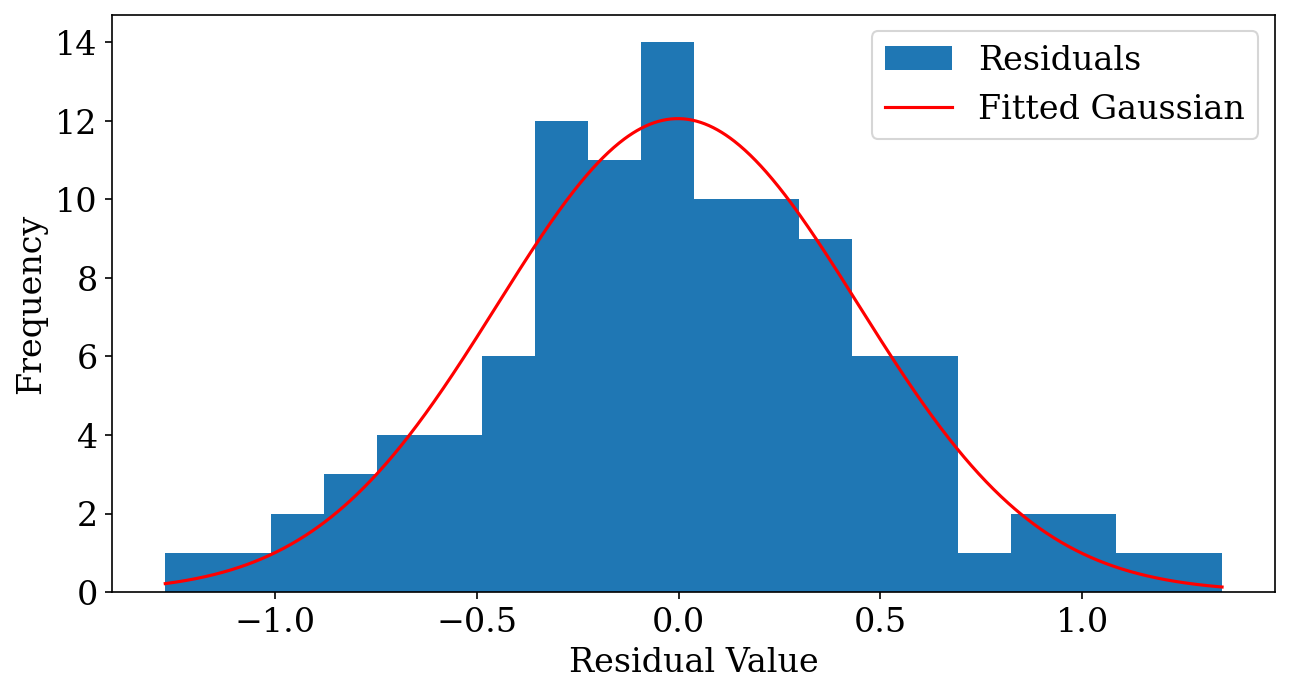

In [90]:
model_plot(lag_times, cf2, result2, LABELS[1], COLORS[1])
display(result2.params)
display(fit_evaluation(result2))
residual_autocorrelation(result2, color=COLORS[1])
residuals_histogram(result2)
T_CF2 = result2.best_values['f1']
n_CF2 = result2.best_values['n']
G0_CF2 = G0(n_CF2,T_CF2)

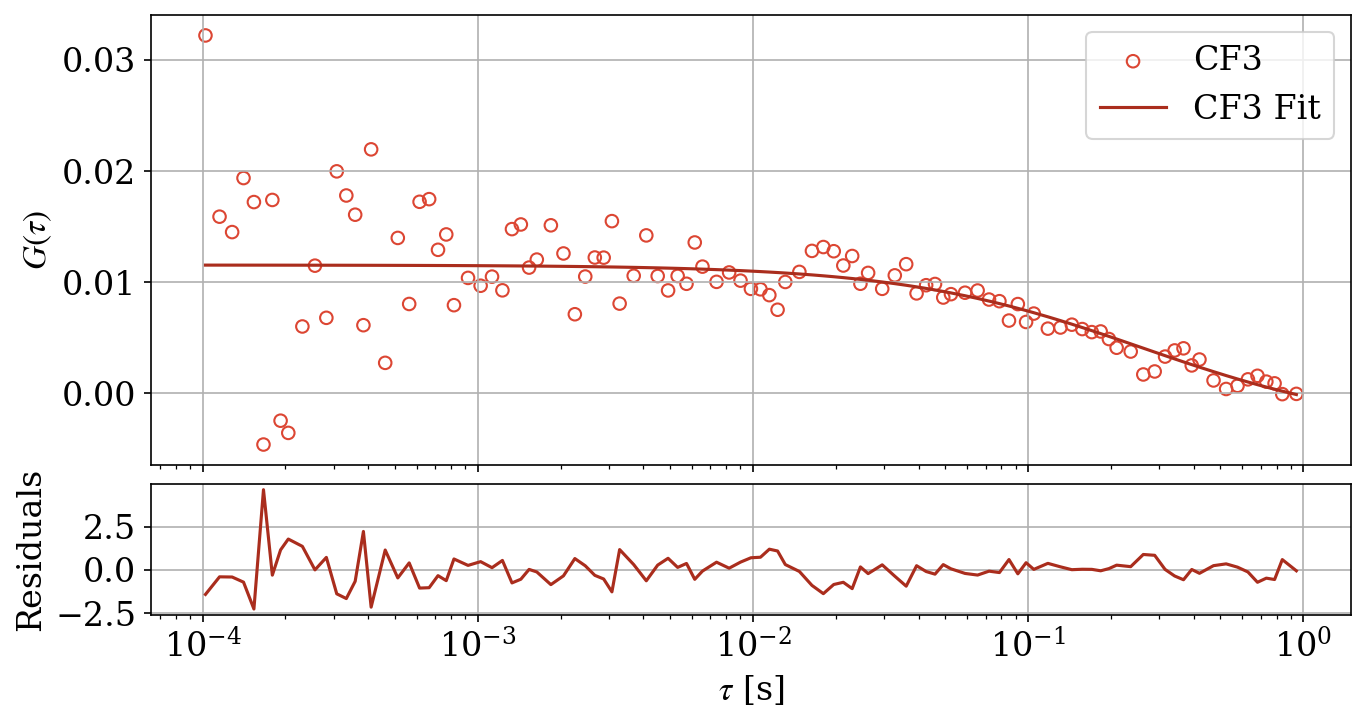

name,value,standard error,relative error,initial value,min,max,vary
n,67.3735753,10.4889912,(15.57%),0.2,1.0000e-03,1000.00000,True
tauD1,9.2205e-04,9809.84810,(1063914996.86%),0.01,1.0000e-04,0.01000000,True
tauD2,0.25775930,0.09780287,(37.94%),0.038,1.0000e-03,1.00000000,True
f1,5.4095e-12,0.00150044,(27737337257.76%),0.5,0.00000000,1.00000000,True
offset,-0.00330433,0.00131489,(39.79%),0,-1.00000000,1.00000000,True


Metric,Score
Reduced Chi-Squared,0.7737
AIC,-22.3134
R Squared,0.4238


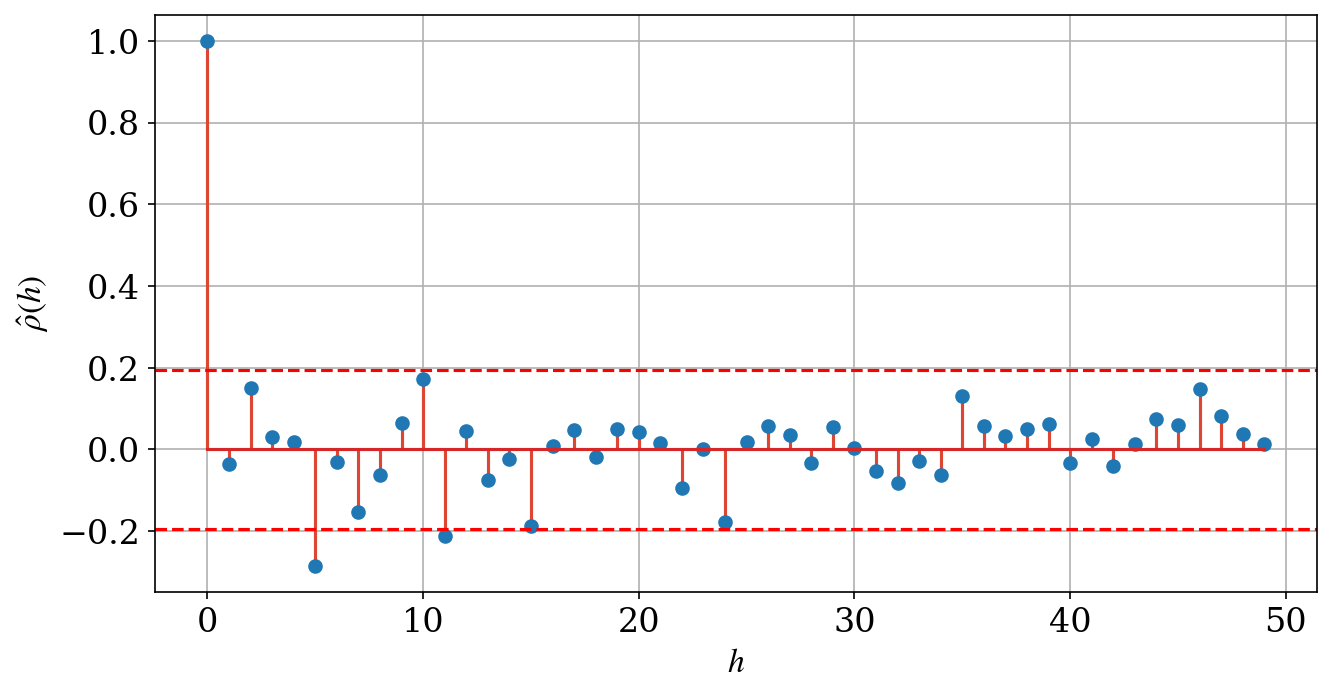

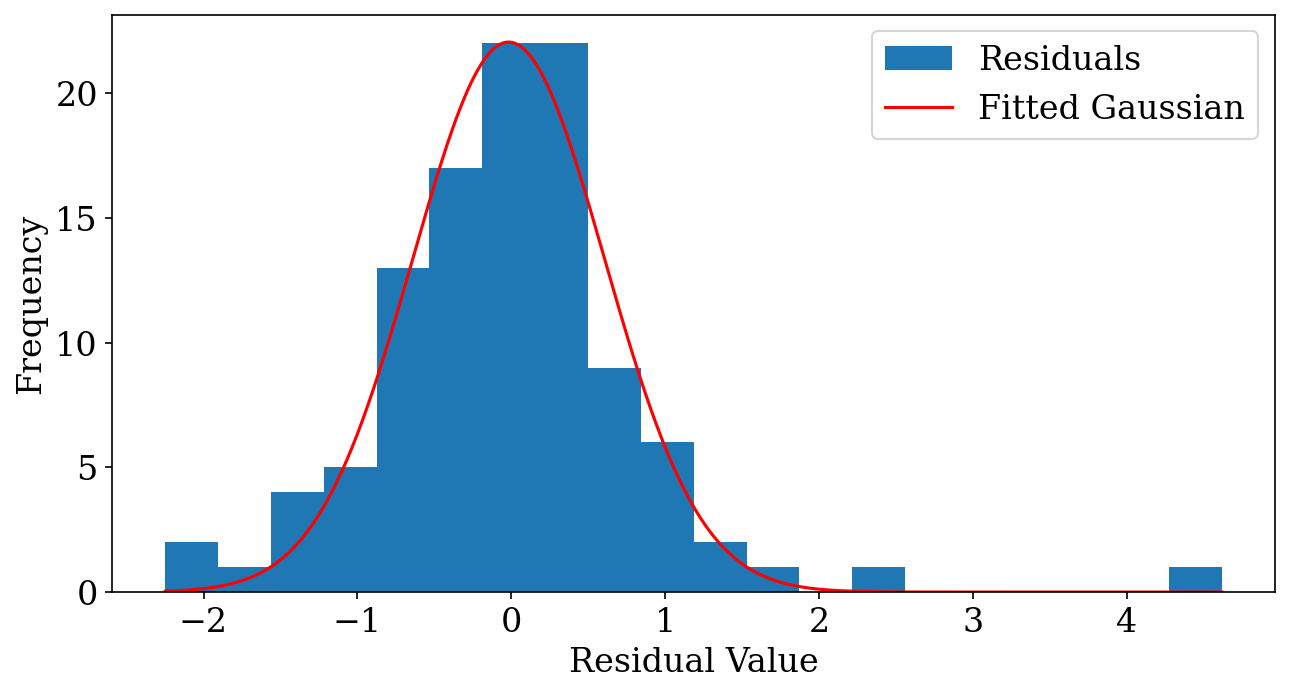

In [91]:
model_plot(lag_times, cf3, result3, LABELS[2], COLORS[2])
display(result3.params)
display(fit_evaluation(result3))
residual_autocorrelation(result3, color=COLORS[2])
residuals_histogram(result3)
T_CF3 = result3.best_values['f1']
n_CF3 = result3.best_values['n']
G0_CF3 = G0(n_CF3,T_CF3)

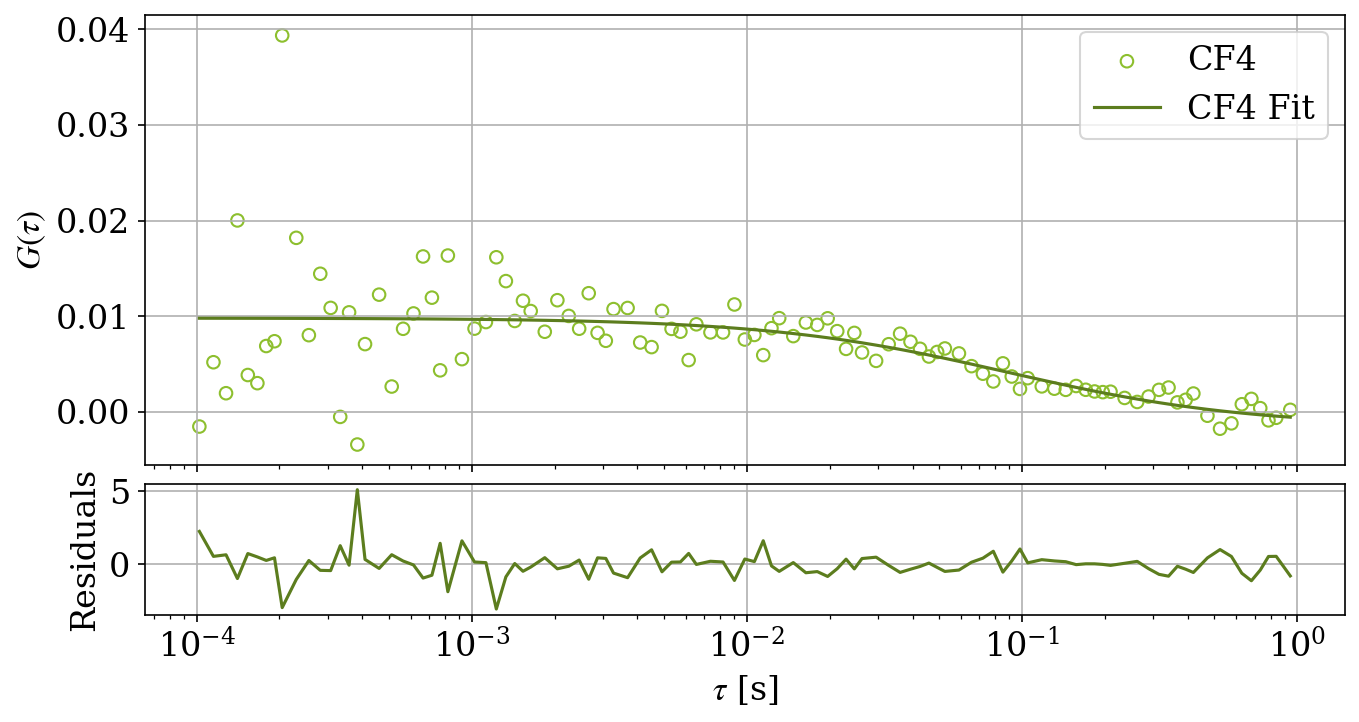

name,value,standard error,relative error,initial value,min,max,vary
n,88.2478227,8.29264614,(9.40%),0.2,1.0000e-03,1000.00000,True
tauD1,0.00998108,319759.670,(3203658671.82%),0.01,1.0000e-04,0.01000000,True
tauD2,0.08881806,0.10322414,(116.22%),0.038,1.0000e-03,1.00000000,True
f1,1.1486e-11,0.01300261,(113199310858.99%),0.5,0.00000000,1.00000000,True
offset,-0.00152532,6.6864e-04,(43.84%),0,-1.00000000,1.00000000,True


Metric,Score
Reduced Chi-Squared,0.8688
AIC,-10.0294
R Squared,0.3813


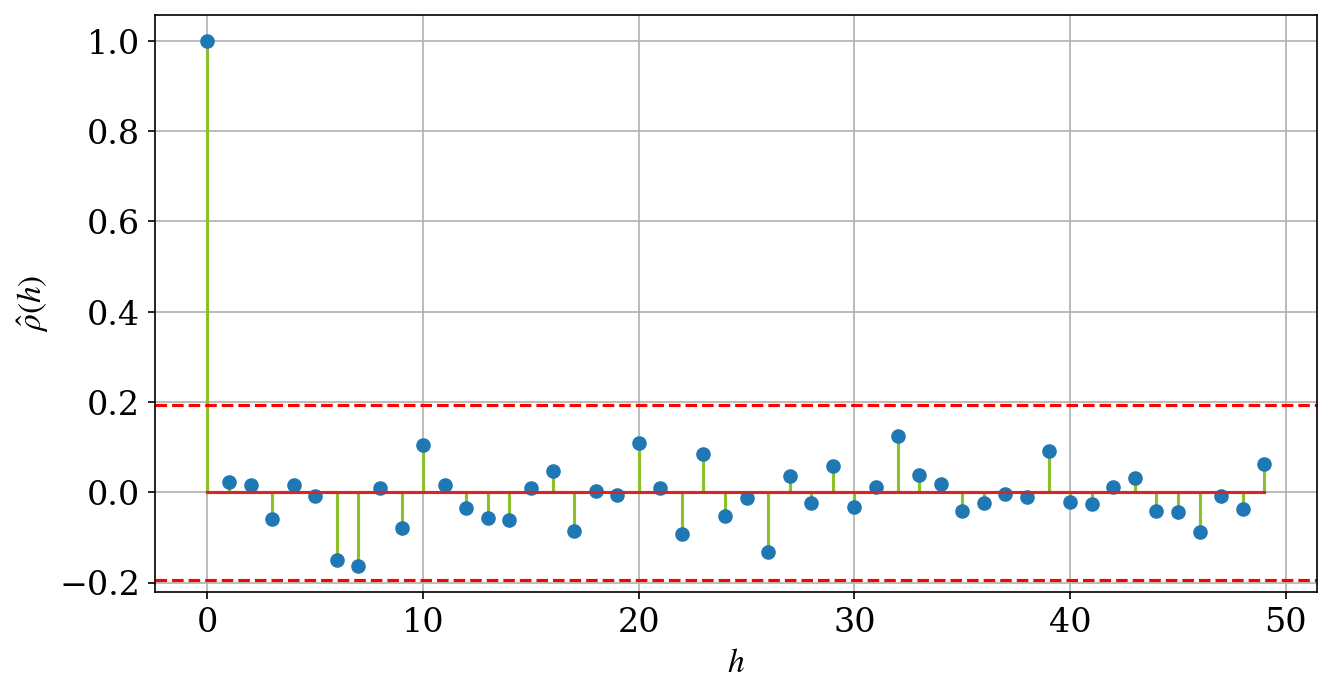

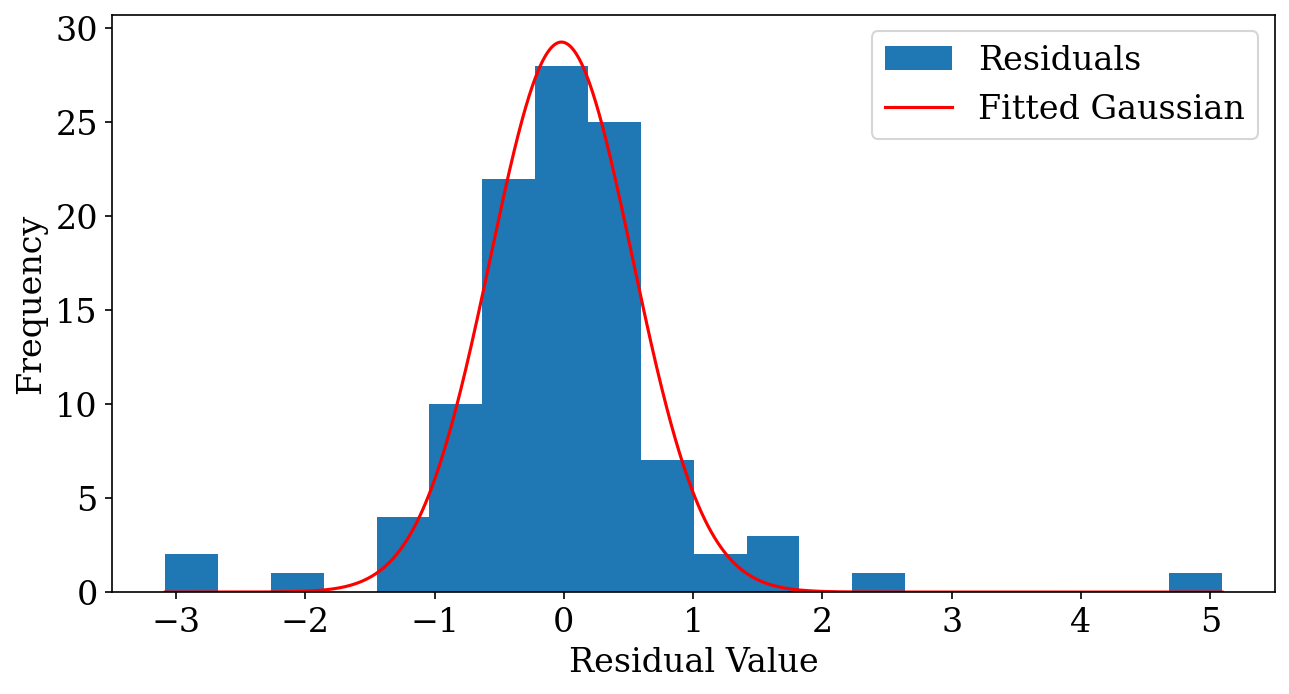

0.011331724332817645


In [92]:
model_plot(lag_times, cf4, result4, LABELS[3], COLORS[3])
display(result4.params)
display(fit_evaluation(result4))
residual_autocorrelation(result4, color=COLORS[3])
residuals_histogram(result4)
T_CF4 = result4.best_values['f1']
n_CF4 = result4.best_values['n']
G0_CF4 = G0(n_CF4,T_CF4)
print(G0_CF4)

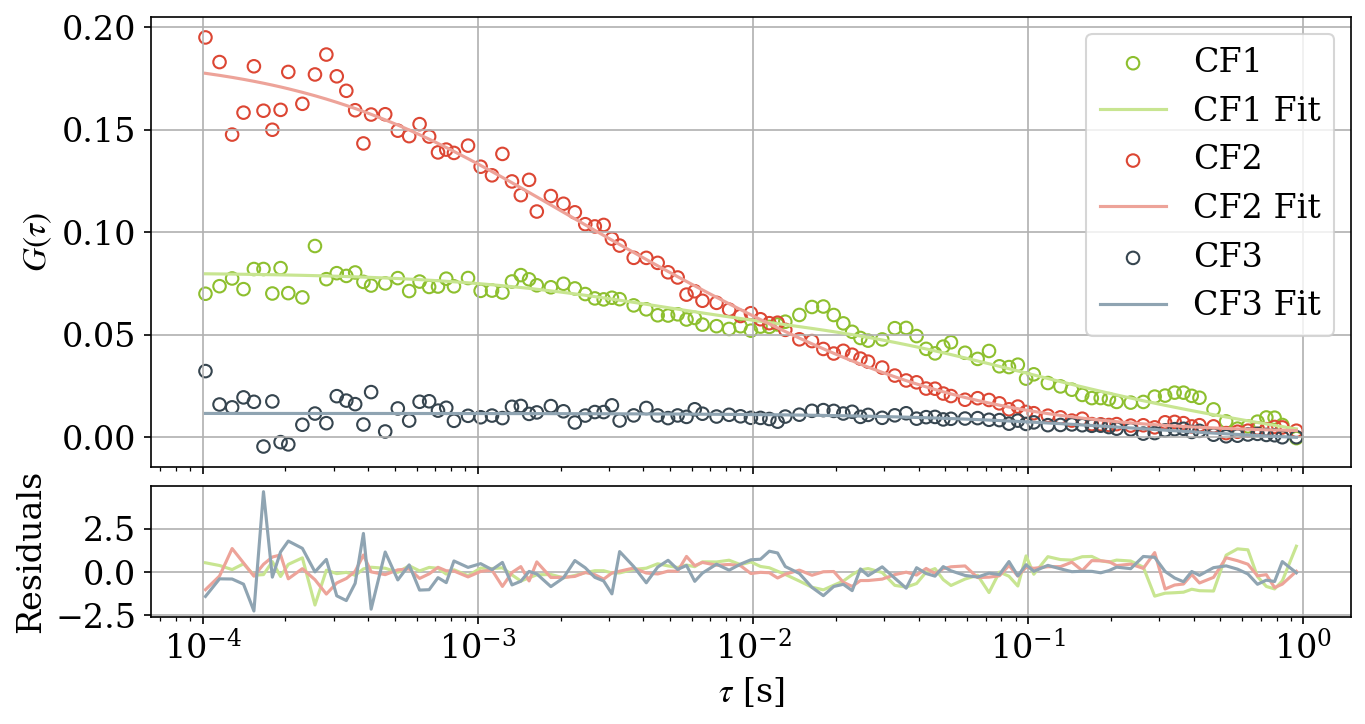

In [93]:
cc_model_plot(lag_times, cf1, result1,cf2, result2, cf3, result3,OVCF_g,OVCF_r,LABELS[3], COLORS[3])


In [94]:
print(G0_CF1/OVCF_g)
print(G0_CF2/OVCF_r)
print(G0_CF3)
Gx_r = G0_CF3/(G0_CF1/OVCF_g)
Gx_g = G0_CF3/(G0_CF2/OVCF_r)

print(Gx_r)
print(Gx_g)

0.06463615956190231
0.07563268231796404
0.014842614425776229
0.22963329700245258
0.19624604034770374


In [95]:
G0_CF1

0.06463615956190231